In [ ]:
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

### Loading the data

In [ ]:

train_dir = '../datasets/melanoma/melanoma_cancer_dataset/train'
test_dir = '../datasets/melanoma/melanoma_cancer_dataset/test'

# Create ImageDataGenerator instance for data augmentation 
train_datagen = ImageDataGenerator(
    rescale=1.0/255,       # Normalize pixel values to [0, 1]
    rotation_range=20,     # Randomly rotate images
    width_shift_range=0.2, # Randomly translate images horizontally
    height_shift_range=0.2,# Randomly translate images vertically
    shear_range=0.2,       # Randomly shear images
    zoom_range=0.2,        # Randomly zoom images
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest',# Fill mode for newly created pixels
    validation_split=0.2, # Specify the validation split
)


test_datagen = ImageDataGenerator(rescale=1.0/255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150), # Resize images to match the input size of the model
    batch_size=32,
    class_mode='binary', 
    subset = "training" 
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'  
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print(train_generator.class_indices)
print(validation_generator.class_indices)
print(test_generator.class_indices)


Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
{'benign': 0, 'malignant': 1}
{'benign': 0, 'malignant': 1}
{'benign': 0, 'malignant': 1}


### There should be some preprocessing steps added here

## Model 1,   THERE'S A BUG THAT NEEDS TO BE FIXED
#### BatchNormalization(), Activation('relu'), filters = (32, 64, 128, 256), kernel_size = (3,3), strides = (1,1), padding = "same", Dropout(0.25)

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
# def deep_cnn1():
#     model = Sequential()

#     model.add(Conv2D(input_shape = (150,3,3), filters = 32, kernel_size = (3,3), strides = (1,1), padding = "same", kernel_initializer='he_normal'))
#     model.add(Dropout(0.25))
#     model.add(BatchNormalization())
#     model.add(Activation("relu"))
#     model.add(MaxPooling2D(pool_size = (2,2)))

#     model.add(Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), padding  = "same", kernel_initializer='he_normal'))
#     model.add(Dropout(0.25))
#     model.add(BatchNormalization())
#     model.add(Activation("relu"))
#     model.add(MaxPooling2D(pool_size = (2,2)))

#     model.add(Conv2D(filters = 128, kernel_size = (3,3), strides = (1,1), padding  = "same", kernel_initializer='he_normal'))
#     model.add(Dropout(0.25))
#     model.add(BatchNormalization())
#     model.add(Activation("relu"))
#     model.add(MaxPooling2D(pool_size = (2,2)))


#     # model.add(Conv2D(filters = 256, kernel_size = (3,3), strides = (1,1), padding  = "same", kernel_initializer='he_normal'))
#     # model.add(Dropout(0.25))
#     # model.add(BatchNormalization())
#     # model.add(Activation("relu"))
#     # model.add(MaxPooling2D(pool_size = (2,2)))
    
#     model.add(Flatten())

#     model.add(Dense(64, activation = "relu", kernel_initializer='he_normal'))
#     model.add(Dense(64, activation = "relu", kernel_initializer='he_normal'))
#     model.add(Dense(2, activation = "softmax", kernel_initializer='he_normal'))

#     adam = optimizers.Adam(learning_rate = 0.01)
#     model.compile(loss= "binary_crossentropy", optimizer = adam, metrics = ["accuracy"])

#     return model
    

In [4]:
#model1 = deep_cnn1()

## Model2
#### BatchNormalization(), Activation('relu'), filters = (32, 64, 128, 256), kernel_size = (3,3), strides = (1,1), padding = "same", Dropout(0.5)**added after flatten**, Adam(learning_rate = 0.01)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))



from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam
from keras.regularizers import l2, l1

# kernel_regularizer=l2(0.01) # not used yet, but should try with this one 

def deep_cnn2():
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(input_shape=(150, 150, 3), filters=32, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Second Convolutional Block
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Third Convolutional Block
    model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Fourth Convolutional Block
    model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation="relu", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))  # Adjusted to 128 units
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid", kernel_initializer='he_normal',kernel_regularizer=l2(0.01)))  # Using sigmoid for binary classification

    adam = Adam(learning_rate=0.001)
    model.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

    return model



In [16]:
model_cnnx = deep_cnn2()

In [17]:


history_model_cnnx= model_cnnx.fit(
    train_generator,
    batch_size = 32,
    epochs=5,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    verbose = 1
)


Epoch 1/5
241/241 [==============================] - 216s 889ms/step - loss: 5.9226 - accuracy: 0.7864 - val_loss: 2.1551 - val_accuracy: 0.8673
Epoch 2/5
241/241 [==============================] - 145s 603ms/step - loss: 1.2775 - accuracy: 0.8192 - val_loss: 1.0072 - val_accuracy: 0.8095
Epoch 3/5
241/241 [==============================] - 146s 604ms/step - loss: 0.8207 - accuracy: 0.7988 - val_loss: 0.8628 - val_accuracy: 0.8126
Epoch 4/5
241/241 [==============================] - 148s 614ms/step - loss: 0.6677 - accuracy: 0.8047 - val_loss: 0.7068 - val_accuracy: 0.8199
Epoch 5/5
241/241 [==============================] - 148s 612ms/step - loss: 0.6338 - accuracy: 0.8022 - val_loss: 0.6837 - val_accuracy: 0.7283


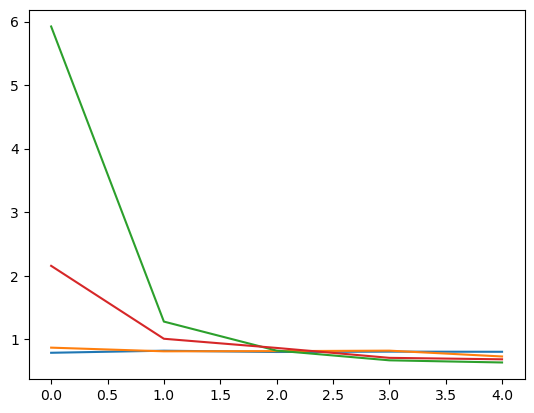

In [18]:
import matplotlib.pyplot as plt
plt.plot(history_model_cnnx.history["accuracy"])
plt.plot(history_model_cnnx.history["val_accuracy"])
plt.plot(history_model_cnnx.history["loss"])
plt.plot(history_model_cnnx.history["val_loss"])

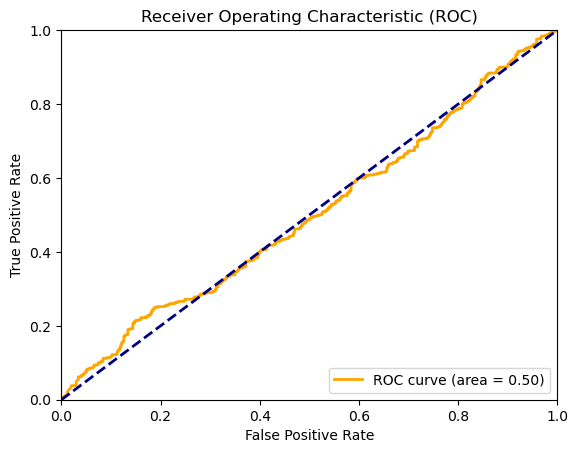

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = test_generator.classes  

y_pred_prob = model_cnn_test  # No slicing needed since it's already the probability

# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='orange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [9]:
# saving the model
# autoencoder.save('autoencoder_model1.h5')
model_cnn.save('model_cnn')

INFO:tensorflow:Assets written to: model_cnn\assets


INFO:tensorflow:Assets written to: model_cnn\assets


In [13]:
model_cnn_test = model_cnnx.predict(test_generator)

32/32 [==============================] - 11s 337ms/step


## Network in Network model

In [20]:
def deep_cnn_nin():
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(input_shape=(150, 150, 3), filters=32, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Activation("relu"))

    # Second Convolutional Block
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))
    model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal')) 
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Third Convolutional Block
    model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Fourth Convolutional Block
    model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))
    model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", kernel_initializer='he_normal'))    
    model.add(Activation("relu"))
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation="relu", kernel_initializer='he_normal'))  # Adjusted to 128 units
    model.add(Dropout(0.25))

    # model.add(Dropout(0.5))
    model.add(Dense(1, activation="softmax", kernel_initializer='he_normal'))  # Using sigmoid for binary classification

    adam = Adam(learning_rate=0.1)
    model.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

    return model



In [21]:
model_nin = deep_cnn_nin()

In [22]:
 history_model_nin = model_nin.fit(
    train_generator,
     batch_size = 32,
    epochs=10,
    validation_data=validation_generator,
 verbose =1 )

Epoch 1/10
241/241 [==============================] - 1015s 4s/step - loss: 16544.9473 - accuracy: 0.4794 - val_loss: 0.6924 - val_accuracy: 0.4794
Epoch 2/10
241/241 [==============================] - 991s 4s/step - loss: 0.7480 - accuracy: 0.4794 - val_loss: 0.6923 - val_accuracy: 0.4794
Epoch 3/10
241/241 [==============================] - 965s 4s/step - loss: 0.8141 - accuracy: 0.4794 - val_loss: 0.6924 - val_accuracy: 0.4794
Epoch 4/10
 79/241 [========>.....................] - ETA: 10:14 - loss: 0.6934 - accuracy: 0.4755

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_model_nin.history["accuracy"])
plt.plot(history_model_nin.history["val_accuracy"])
plt.plot(history_model_nin.history["loss"])
plt.plot(history_model_nin.history["val_loss"])

In [ ]:
history_model_nin.save('history_model_nin')

In [ ]:
history_model_nin = model_nin.predict(test_generator)

## Autoencoders model

### Loading the data

In [ ]:
# Directory paths
train_dir = '../datasets/melanoma/melanoma_cancer_dataset/train'
test_dir = '../datasets/melanoma/melanoma_cancer_dataset/test'



train_generator_ae = train_datagen.flow_from_directory(
    '../datasets/melanoma/melanoma_cancer_dataset/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode=None,  
    subset = "training"
)

validation_generator_ae = train_datagen.flow_from_directory(
    '../datasets/melanoma/melanoma_cancer_dataset/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode=None,  
    subset = "validation"
)


# Custom generator to remove labels
def remove_labels(generator):
    while True:
        x = next(generator)
        yield x, x

train_generator_no_labels = remove_labels(train_generator_ae)
validation_generator_no_labels = remove_labels(train_generator_ae)

Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.


### Building a model

In [ ]:
# building an autoencoder model

from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D

def build_autoencoder():
    input_img = Input(shape=(150, 150, 3))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    
    x = Cropping2D(((1, 1), (1, 1)))(x)  # Crops 1 pixel on all sides

    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # Autoencoder Model
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder

autoencoder = build_autoencoder()

autoencoder.summary()


Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 conv2d_60 (Conv2D)          (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d_28 (MaxPoolin  (None, 75, 75, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_61 (Conv2D)          (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_29 (MaxPoolin  (None, 38, 38, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_62 (Conv2D)          (None, 38, 38, 128)       7385

### Fitting the model

In [26]:
history_autoencoder = autoencoder.fit(
    train_generator_no_labels,
    epochs=50,
    validation_data=validation_generator_no_labels,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    ]
)


Epoch 1/50
241/241 [==============================] - 182s 751ms/step - loss: 0.0063 - val_loss: 0.0014 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 179s 745ms/step - loss: 0.0012 - val_loss: 9.7035e-04 - lr: 0.0010
Epoch 3/50
241/241 [==============================] - 178s 739ms/step - loss: 9.2294e-04 - val_loss: 7.7740e-04 - lr: 0.0010
Epoch 4/50
241/241 [==============================] - 178s 740ms/step - loss: 8.0622e-04 - val_loss: 7.5470e-04 - lr: 0.0010
Epoch 5/50
241/241 [==============================] - 178s 739ms/step - loss: 7.7068e-04 - val_loss: 7.6557e-04 - lr: 0.0010
Epoch 6/50
241/241 [==============================] - 178s 738ms/step - loss: 7.0755e-04 - val_loss: 9.7995e-04 - lr: 0.0010
Epoch 7/50
241/241 [==============================] - 178s 740ms/step - loss: 6.9351e-04 - val_loss: 6.2240e-04 - lr: 0.0010
Epoch 8/50
241/241 [==============================] - 178s 737ms/step - loss: 6.7612e-04 - val_loss: 6.3601e-04 - lr: 0.0010
Epoch 9/50
2

In [27]:
# saving the model
# autoencoder.save('autoencoder_model1.h5')
autoencoder.save('autoencoder_model1')


INFO:tensorflow:Assets written to: autoencoder_model1\assets


INFO:tensorflow:Assets written to: autoencoder_model1\assets


In [28]:
# saving the model

# autoencoder.save('autoencoder_model1.h5')
autoencoder.save('autoencoder_model1')


INFO:tensorflow:Assets written to: autoencoder_model1\assets


INFO:tensorflow:Assets written to: autoencoder_model1\assets


In [ ]:
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Found 1000 images belonging to 2 classes.
1/1 [==============================] - 0s 317ms/step


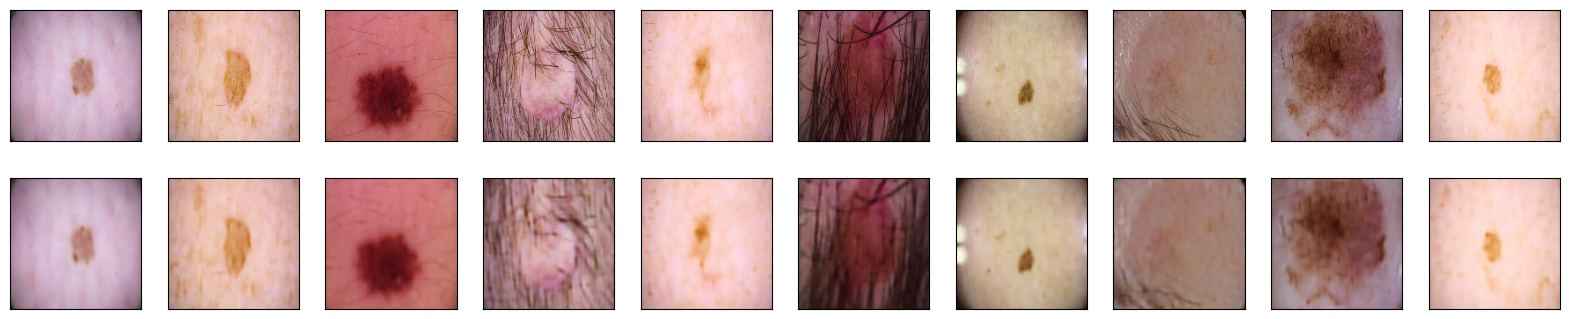

In [ ]:
# Load the saved autoencoder model
autoencoder = load_model('autoencoder_model1')

# Directory path to test data
test_dir = '../datasets/melanoma/melanoma_cancer_dataset/test'

# Data generator for test data
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator_no_labels = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode=None,  # Ensure no labels are used
    shuffle=False
)

# Generate predictions for the test dataset
test_images = next(test_generator_no_labels)
decoded_images = autoencoder.predict(test_images)

# Visualize the original and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_images[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


## Sparse Autoencoder

In [30]:
train_generator_no_labels, validation_generator_no_labels

(<generator object remove_labels at 0x0000026AC0793ED0>,
 <generator object remove_labels at 0x0000026AC0792810>)

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from keras import regularizers

In [ ]:
def build_sparse_autoencoder():
    input_img = Input(shape=(150, 150, 3))

    sparsity_constraint = 1e-5

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same', activity_regularizer=regularizers.l1(sparsity_constraint))(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', activity_regularizer=regularizers.l1(sparsity_constraint))(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # x = Conv2D(128, (3, 3), activation='relu', padding='same', activity_regularizer=regularizers.l1(sparsity_constraint))(x)
    # encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    # x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    # x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    
    x = Cropping2D(((1, 1), (1, 1)))(x)  # Crops 1 pixel on all sides

    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # Autoencoder Model
    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder

sparse_autoencoder = build_sparse_autoencoder()

sparse_autoencoder.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 75, 75, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 38, 38, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 38, 38, 64)        36928 

In [7]:
history_sa = sparse_autoencoder.fit(
    train_generator_no_labels,
    epochs=20,
    validation_data=validation_generator_no_labels,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
    ]
)

Epoch 1/20
241/241 [==============================] - 321s 1s/step - loss: 0.0216 - val_loss: 0.0101 - lr: 0.0010
Epoch 2/20
241/241 [==============================] - 247s 1s/step - loss: 0.0093 - val_loss: 0.0084 - lr: 0.0010
Epoch 3/20
241/241 [==============================] - 214s 888ms/step - loss: 0.0084 - val_loss: 0.0075 - lr: 0.0010
Epoch 4/20
241/241 [==============================] - 215s 894ms/step - loss: 0.0081 - val_loss: 0.0086 - lr: 0.0010
Epoch 5/20
241/241 [==============================] - 215s 892ms/step - loss: 0.0073 - val_loss: 0.0073 - lr: 0.0010
Epoch 6/20
241/241 [==============================] - 215s 894ms/step - loss: 0.0071 - val_loss: 0.0066 - lr: 0.0010
Epoch 7/20
241/241 [==============================] - 215s 894ms/step - loss: 0.0068 - val_loss: 0.0063 - lr: 0.0010
Epoch 8/20
241/241 [==============================] - 216s 896ms/step - loss: 0.0064 - val_loss: 0.0061 - lr: 0.0010
Epoch 9/20
241/241 [==============================] - 218s 905ms/step 

dict_keys(['loss', 'val_loss', 'lr'])


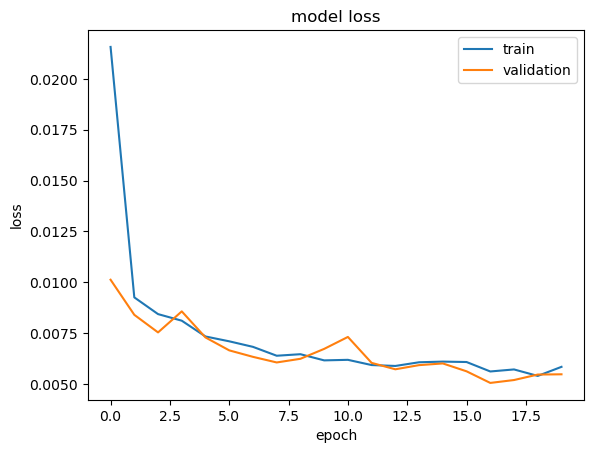

In [ ]:
print(history_sa.history.keys())

plt.plot(history_sa.history['loss'])
plt.plot(history_sa.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [11]:
sparse_autoencoder.save("sparse_autoencoder")

INFO:tensorflow:Assets written to: sparse_autoencoder\assets


INFO:tensorflow:Assets written to: sparse_autoencoder\assets


Found 1000 images belonging to 2 classes.
1/1 [==============================] - 1s 552ms/step


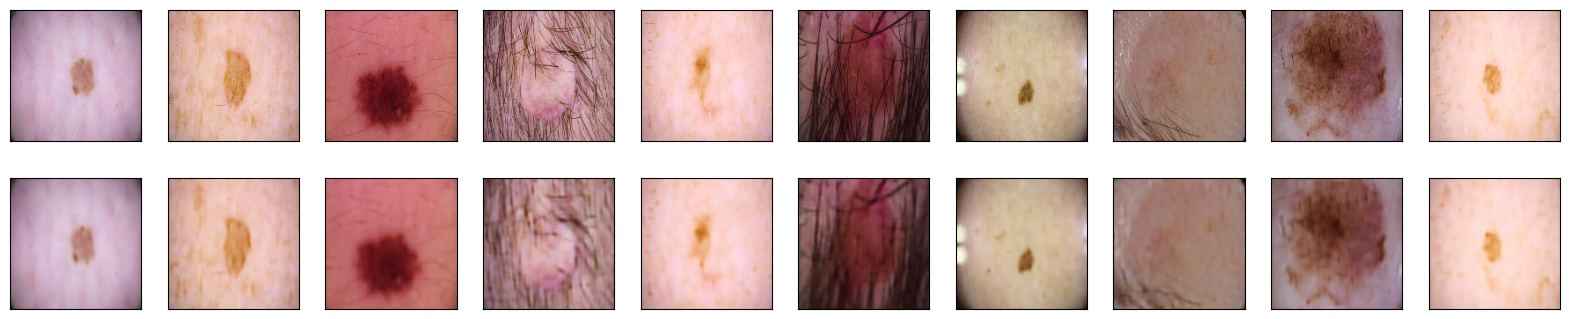

In [ ]:
# Load the saved autoencoder model
autoencoder = load_model('autoencoder_model1')

# Directory path to test data
test_dir = '../datasets/melanoma/melanoma_cancer_dataset/test'

# Data generator for test data
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator_no_labels = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode=None, 
    shuffle=False
)

# Generate predictions for the test dataset
test_images = next(test_generator_no_labels)
decoded_images = autoencoder.predict(test_images)

# Visualize the original and reconstructed images
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_images[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()


### VGG Net

In [ ]:
from keras.applications import VGG16, ResNet50
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Add custom top layers for our specific classification task
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) 

# Combine the base model and the custom layers
model_vgg = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model_vgg.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])


In [5]:
 history_vgg = model_vgg.fit(
    train_generator,
     batch_size = 32,
    epochs=20,
    validation_data=validation_generator,
 verbose =1 )

Epoch 1/20
241/241 [==============================] - 430s 2s/step - loss: 0.4135 - accuracy: 0.8147 - val_loss: 0.3317 - val_accuracy: 0.8652
Epoch 2/20
241/241 [==============================] - 413s 2s/step - loss: 0.3474 - accuracy: 0.8492 - val_loss: 0.3360 - val_accuracy: 0.8522
Epoch 3/20
241/241 [==============================] - 414s 2s/step - loss: 0.3200 - accuracy: 0.8634 - val_loss: 0.3119 - val_accuracy: 0.8745
Epoch 4/20
241/241 [==============================] - 444s 2s/step - loss: 0.3040 - accuracy: 0.8718 - val_loss: 0.2801 - val_accuracy: 0.8902
Epoch 5/20
241/241 [==============================] - 457s 2s/step - loss: 0.2942 - accuracy: 0.8762 - val_loss: 0.2803 - val_accuracy: 0.8865
Epoch 6/20
241/241 [==============================] - 440s 2s/step - loss: 0.2961 - accuracy: 0.8701 - val_loss: 0.2885 - val_accuracy: 0.8704
Epoch 7/20
241/241 [==============================] - 424s 2s/step - loss: 0.2909 - accuracy: 0.8709 - val_loss: 0.2891 - val_accuracy: 0.8771

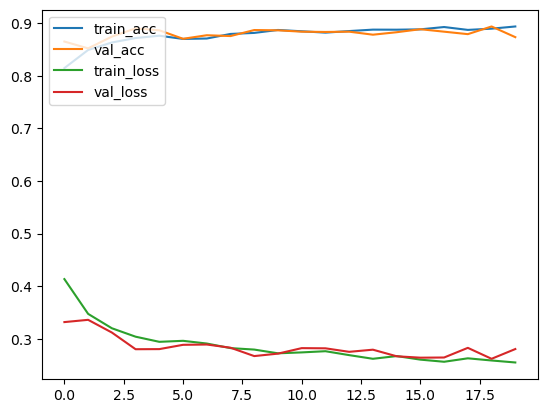

In [ ]:
plt.plot( history_vgg.history["accuracy"])
plt.plot( history_vgg.history["val_accuracy"])
plt.plot( history_vgg.history["loss"])
plt.plot( history_vgg.history["val_loss"])
plt.legend(['train_acc', 'val_acc', "train_loss", "val_loss"], loc='upper left')


In [10]:
# model_vgg.save('model_vgg.h5')
model_vgg.save('model_vgg')


INFO:tensorflow:Assets written to: model_vgg\assets


INFO:tensorflow:Assets written to: model_vgg\assets


In [11]:
test_vgg = model_vgg.predict(test_generator)

32/32 [==============================] - 34s 1s/step


### ResNet

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense

In [ ]:
# Load the ResNet50 model, excluding the top classification layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Add custom top layers for our specific classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

# Combine the base model and the custom layers
model_resnet50 = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

model_resnet50.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

model_resnet50.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 150, 150, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 156, 156, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 75, 75, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 75, 75, 64)   256         ['conv1_conv[0][0]']       

In [15]:
history_resnet50 = model_resnet50.fit(
    train_generator,
     batch_size = 32,
    epochs=20,
    validation_data=validation_generator,
 verbose =1 )

Epoch 1/20
241/241 [==============================] - 166s 687ms/step - loss: 0.7090 - accuracy: 0.5319 - val_loss: 0.6683 - val_accuracy: 0.6372
Epoch 2/20
241/241 [==============================] - 162s 671ms/step - loss: 0.6763 - accuracy: 0.5717 - val_loss: 0.6557 - val_accuracy: 0.5997
Epoch 3/20
241/241 [==============================] - 166s 690ms/step - loss: 0.6535 - accuracy: 0.6161 - val_loss: 0.6430 - val_accuracy: 0.6424
Epoch 4/20
241/241 [==============================] - 160s 663ms/step - loss: 0.6395 - accuracy: 0.6359 - val_loss: 0.6313 - val_accuracy: 0.6455
Epoch 5/20
241/241 [==============================] - 165s 682ms/step - loss: 0.6241 - accuracy: 0.6636 - val_loss: 0.6214 - val_accuracy: 0.6465
Epoch 6/20
241/241 [==============================] - 164s 681ms/step - loss: 0.6187 - accuracy: 0.6668 - val_loss: 0.6063 - val_accuracy: 0.6996
Epoch 7/20
241/241 [==============================] - 166s 686ms/step - loss: 0.6056 - accuracy: 0.6832 - val_loss: 0.5998 -

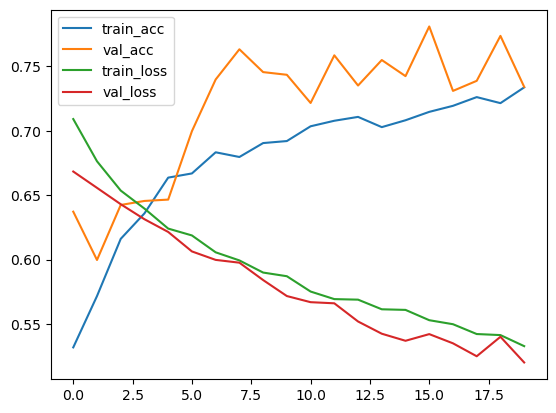

In [21]:
plt.plot(history_resnet50.history["accuracy"])
plt.plot(history_resnet50.history["val_accuracy"])
plt.plot(history_resnet50.history["loss"])
plt.plot(history_resnet50.history["val_loss"])
plt.legend(['train_acc', 'val_acc', "train_loss", "val_loss"], loc='upper left')


In [17]:
model_resnet50.save("model_resnet50")

INFO:tensorflow:Assets written to: model_resnet50\assets


INFO:tensorflow:Assets written to: model_resnet50\assets


In [18]:
test_resnet50 = model_resnet50.predict(test_generator)

32/32 [==============================] - 20s 567ms/step


### Ensemble Method

In [ ]:
from keras.applications import ResNet50, VGG16, MobileNet
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import Adam

In [ ]:
# Base Model 1: Simple CNN
def create_cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn_model()
cnn_model.fit(train_generator, validation_data=validation_generator, epochs=5)

# Base Model 2: ResNet50
def create_resnet_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False  # Freeze the base model

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

resnet_model = create_resnet_model()
resnet_model.fit(train_generator, validation_data=validation_generator, epochs=5)

# Base Model 3: VGG16
def create_vgg16_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False  # Freeze the base model

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

vgg16_model = create_vgg16_model()
vgg16_model.fit(train_generator, validation_data=validation_generator, epochs=5)

# Base Model 4: MobileNet
def create_mobilenet_model():
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    base_model.trainable = False  # Freeze the base model

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

mobilenet_model = create_mobilenet_model()
mobilenet_model.fit(train_generator, validation_data=validation_generator, epochs=5)


Epoch 1/5
241/241 [==============================] - 158s 651ms/step - loss: 0.4877 - accuracy: 0.7695 - val_loss: 0.3472 - val_accuracy: 0.8558
Epoch 2/5
241/241 [==============================] - 157s 653ms/step - loss: 0.3562 - accuracy: 0.8431 - val_loss: 0.3308 - val_accuracy: 0.8516
Epoch 3/5
241/241 [==============================] - 157s 652ms/step - loss: 0.3338 - accuracy: 0.8581 - val_loss: 0.3235 - val_accuracy: 0.8730
Epoch 4/5
241/241 [==============================] - 153s 636ms/step - loss: 0.3121 - accuracy: 0.8695 - val_loss: 0.3217 - val_accuracy: 0.8553
Epoch 5/5
241/241 [==============================] - 152s 629ms/step - loss: 0.3025 - accuracy: 0.8709 - val_loss: 0.3151 - val_accuracy: 0.8839
Epoch 1/5
241/241 [==============================] - 197s 795ms/step - loss: 0.6816 - accuracy: 0.6351 - val_loss: 0.5203 - val_accuracy: 0.7652
Epoch 2/5
241/241 [==============================] - 188s 778ms/step - loss: 0.5449 - accuracy: 0.7108 - val_loss: 0.5400 - val_ac

17225924/17225924 [==============================] - 3s 0us/step
Epoch 1/5
241/241 [==============================] - 138s 561ms/step - loss: 0.4278 - accuracy: 0.8639 - val_loss: 0.2977 - val_accuracy: 0.8673
Epoch 2/5
241/241 [==============================] - 134s 556ms/step - loss: 0.2592 - accuracy: 0.8974 - val_loss: 0.2533 - val_accuracy: 0.8938
Epoch 3/5
241/241 [==============================] - 134s 554ms/step - loss: 0.2354 - accuracy: 0.9023 - val_loss: 0.2538 - val_accuracy: 0.8860
Epoch 4/5
241/241 [==============================] - 134s 556ms/step - loss: 0.2321 - accuracy: 0.9079 - val_loss: 0.2578 - val_accuracy: 0.8907
Epoch 5/5
241/241 [==============================] - 134s 554ms/step - loss: 0.2270 - accuracy: 0.9080 - val_loss: 0.2622 - val_accuracy: 0.9032


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Generate predictions for the validation set
cnn_predictions = cnn_model.predict(test_generator)
resnet_predictions = resnet_model.predict(test_generator)
vgg16_predictions = vgg16_model.predict(test_generator)
mobilenet_predictions = mobilenet_model.predict(test_generator)

# Combine predictions as new features
stacked_predictions = np.column_stack((cnn_predictions, resnet_predictions, vgg16_predictions, mobilenet_predictions))

true_labels = validation_generator.classes

# Train a meta-classifier on the stacked predictions
meta_clf = LogisticRegression()
meta_clf.fit(stacked_predictions, true_labels)

# Evaluate the meta-classifier
meta_predictions = meta_clf.predict(stacked_predictions)
accuracy = accuracy_score(true_labels, meta_predictions)
print(f'Ensemble model accuracy: {accuracy}')


In [ ]:
# Generate predictions for the validation set
cnn_predictions = cnn_model.predict(test_generator)
resnet_predictions = resnet_model.predict(test_generator)
vgg16_predictions = vgg16_model.predict(test_generator)
mobilenet_predictions = mobilenet_model.predict(test_generator)

# Check the shapes of predictions
print(cnn_predictions.shape)
print(resnet_predictions.shape)
print(vgg16_predictions.shape)
print(mobilenet_predictions.shape)

# Ensure predictions are consistent in shape
if cnn_predictions.shape[0] == resnet_predictions.shape[0] == vgg16_predictions.shape[0] == mobilenet_predictions.shape[0]:
    # Combine predictions as new features
    stacked_predictions = np.column_stack((cnn_predictions, resnet_predictions, vgg16_predictions, mobilenet_predictions))
else:
    raise ValueError("Mismatch in number of samples between models.")

# Get true labels
true_labels = test_generator.classes

# Check the shape of true_labels
print(true_labels.shape)

# Ensure true_labels match the number of predictions
if true_labels.shape[0] != stacked_predictions.shape[0]:
    raise ValueError("Mismatch in number of samples between predictions and true labels.")

# Train a meta-classifier on the stacked predictions
meta_clf = LogisticRegression()
meta_clf.fit(stacked_predictions, true_labels)

# Evaluate the meta-classifier
meta_predictions = meta_clf.predict(stacked_predictions)
accuracy = accuracy_score(true_labels, meta_predictions)
print(f'Ensemble model accuracy: {accuracy}')


32/32 [==============================] - 4s 131ms/step
(1000, 1)
(1000, 1)
(1000, 1)
(1000, 1)
(1000,)
Ensemble model accuracy: 0.527
